In [49]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("All libraries imported successfully!")

TensorFlow Version: 2.21.0
NumPy Version: 1.26.4
All libraries imported successfully!


In [50]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [51]:
dataset_path = "/home/sneha/Desktop/FoodFreshness/dataset"

print("Dataset Path:", dataset_path)
print("Dataset Exists:", os.path.exists(dataset_path))

Dataset Path: /home/sneha/Desktop/FoodFreshness/dataset
Dataset Exists: True


In [52]:
class_names = sorted([
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Class Names:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

print("\nTotal Classes:", len(class_names))

Class Names:
0 : fresh_bread
1 : fresh_dairy
2 : fresh_fruits
3 : fresh_vegetables
4 : spoiled_bread
5 : spoiled_dairy
6 : spoiled_fruits
7 : spoiled_vegetables

Total Classes: 8


In [53]:
valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("Image Count Per Class:\n")

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    image_count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    )

    print(f"{class_name}: {image_count}")

Image Count Per Class:

fresh_bread: 237
fresh_dairy: 215
fresh_fruits: 294
fresh_vegetables: 291
spoiled_bread: 213
spoiled_dairy: 235
spoiled_fruits: 265
spoiled_vegetables: 260


In [54]:
from sklearn.model_selection import train_test_split

# Random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Create split directories
split_path = "/home/sneha/Desktop/FoodFreshness/split_dataset"

train_path = os.path.join(split_path, "train")
val_path = os.path.join(split_path, "validation")
test_path = os.path.join(split_path, "test")

# Create directories
for path in [train_path, val_path, test_path]:
    os.makedirs(path, exist_ok=True)

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Split each class
for class_name in class_names:

    source_dir = os.path.join(dataset_path, class_name)

    # Get all image files
    images = [
        file for file in os.listdir(source_dir)
        if file.lower().endswith(valid_extensions)
    ]

    # First split: 70% train, 30% temporary
    train_images, temp_images = train_test_split(
        images,
        test_size=(val_ratio + test_ratio),
        random_state=42
    )

    # Second split: temporary into validation and test
    val_images, test_images = train_test_split(
        temp_images,
        test_size=test_ratio / (val_ratio + test_ratio),
        random_state=42
    )

    # Create class folders
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

    # Copy images
    for image in train_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(train_path, class_name, image)
        )

    for image in val_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(val_path, class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(source_dir, image),
            os.path.join(test_path, class_name, image)
        )

print("Dataset split completed successfully!")

Dataset split completed successfully!


In [55]:
def count_images_in_folder(folder_path):
    counts = {}

    for class_name in class_names:
        class_dir = os.path.join(folder_path, class_name)

        counts[class_name] = len([
            file for file in os.listdir(class_dir)
            if file.lower().endswith(valid_extensions)
        ])

    return counts


train_counts = count_images_in_folder(train_path)
val_counts = count_images_in_folder(val_path)
test_counts = count_images_in_folder(test_path)

print("TRAIN")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nVALIDATION")
for class_name, count in val_counts.items():
    print(f"{class_name}: {count}")

print("\nTEST")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}")

TRAIN
fresh_bread: 165
fresh_dairy: 150
fresh_fruits: 205
fresh_vegetables: 203
spoiled_bread: 149
spoiled_dairy: 164
spoiled_fruits: 185
spoiled_vegetables: 182

VALIDATION
fresh_bread: 36
fresh_dairy: 32
fresh_fruits: 44
fresh_vegetables: 44
spoiled_bread: 32
spoiled_dairy: 35
spoiled_fruits: 40
spoiled_vegetables: 39

TEST
fresh_bread: 36
fresh_dairy: 33
fresh_fruits: 45
fresh_vegetables: 44
spoiled_bread: 32
spoiled_dairy: 36
spoiled_fruits: 40
spoiled_vegetables: 39


In [56]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [57]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

In [58]:
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [59]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

Found 1400 images belonging to 8 classes.


In [60]:
validation_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 302 images belonging to 8 classes.


In [61]:
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 301 images belonging to 8 classes.


In [62]:
print("Class Mapping:")
print(train_generator.class_indices)

Class Mapping:
{'fresh_bread': 0, 'fresh_dairy': 1, 'fresh_fruits': 2, 'fresh_vegetables': 3, 'spoiled_bread': 4, 'spoiled_dairy': 5, 'spoiled_fruits': 6, 'spoiled_vegetables': 7}


In [63]:
base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("EfficientNetV2B0 loaded successfully!")

EfficientNetV2B0 loaded successfully!


In [64]:
base_model.trainable = False

print("Base model frozen!")

Base model frozen!


In [65]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dropout(0.3),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        8,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,254,424 (23.86 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

In [66]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [67]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "/home/sneha/Desktop/FoodFreshness/models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks ready!")

Callbacks ready!


In [68]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/15
26/44 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2002 - loss: 2.6265

W0000 00:00:1784723823.227088   61979 op_kernel.cc:1845] UNKNOWN: UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7eb8e30ea110>
Traceback (most recent call last):

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py", line 264, in _finite_generator
    yield self._standardize_batch(self.py_dat

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7eb8e30ea110>
Traceback (most recent call last):

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/ops/script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/autograph/impl/api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/tensorflow/python/data/ops/from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "/home/sneha/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py", line 264, in _fin

In [69]:
from PIL import Image
import os

def find_corrupted_images(folder_path):

    corrupted = []

    for root, dirs, files in os.walk(folder_path):

        for file in files:

            file_path = os.path.join(root, file)

            try:
                with Image.open(file_path) as img:
                    img.verify()

            except Exception as e:
                corrupted.append(file_path)

    return corrupted


print("Checking Train...")
bad_train = find_corrupted_images(train_path)

print("Checking Validation...")
bad_val = find_corrupted_images(val_path)

print("Checking Test...")
bad_test = find_corrupted_images(test_path)


print("\nCorrupted files found:")
print("Train:", len(bad_train))
print("Validation:", len(bad_val))
print("Test:", len(bad_test))

Checking Train...
Checking Validation...
Checking Test...

Corrupted files found:
Train: 1
Validation: 1
Test: 0


In [70]:
# Delete corrupted images from train and validation

for file in bad_train + bad_val:
    print("Deleting:", file)
    os.remove(file)

print("\nCorrupted files deleted successfully!")

Deleting: /home/sneha/Desktop/FoodFreshness/split_dataset/train/fresh_bread/photo-1559811814-e2c57b5e69df.jpg
Deleting: /home/sneha/Desktop/FoodFreshness/split_dataset/validation/spoiled_dairy/spoiled curd - Google Search.jpg

Corrupted files deleted successfully!


In [71]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Generators recreated successfully!")

Found 1399 images belonging to 8 classes.
Found 301 images belonging to 8 classes.
Found 301 images belonging to 8 classes.
Generators recreated successfully!


In [72]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=callbacks
)


Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3989 - loss: 1.7793
Epoch 1: val_accuracy improved from None to 0.64120, saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras

Epoch 1: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3989 - loss: 1.7793 - val_accuracy: 0.6412 - val_loss: 1.3664 - learning_rate: 1.0000e-04
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5096 - loss: 1.4114
Epoch 2: val_accuracy improved from 0.64120 to 0.71096, saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras

Epoch 2: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5096 - loss: 1.4114 - val_accuracy: 0.7110 - val_loss: 1.0782 - learning_rate: 1.0000e-04
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6140 - loss: 1.1570
Epoch 3: val_accuracy 

In [73]:
from tensorflow.keras.models import load_model

model = load_model(
    "/home/sneha/Desktop/FoodFreshness/models/best_model.keras"
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [74]:
# Get EfficientNetV2B0 base model
base_model = model.layers[0]

# First freeze everything
base_model.trainable = False

# Unfreeze only the last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

print("Total layers:", len(base_model.layers))

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Total layers: 270
Trainable layers:
input_layer_1
block6g_dwconv2
block6g_bn
block6g_activation
block6g_se_squeeze
block6g_se_reshape
block6g_se_reduce
block6g_se_expand
block6g_se_excite
block6g_project_conv
block6g_project_bn
block6g_drop
block6g_add
block6h_expand_conv
block6h_expand_bn
block6h_expand_activation
block6h_dwconv2
block6h_bn
block6h_activation
block6h_se_squeeze
block6h_se_reshape
block6h_se_reduce
block6h_se_expand
block6h_se_excite
block6h_project_conv
block6h_project_bn
block6h_drop
block6h_add
top_conv
top_bn
top_activation


In [75]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [76]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    ReduceLROnPlateau,
    EarlyStopping
)

fine_tune_callbacks = [

    ModelCheckpoint(
        "/home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

print("Fine-tuning callbacks ready!")

Fine-tuning callbacks ready!


In [77]:
fine_tune_history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=fine_tune_callbacks
)

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7620 - loss: 0.6314
Epoch 1: val_accuracy improved from None to 0.81395, saving model to /home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras

Epoch 1: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7620 - loss: 0.6314 - val_accuracy: 0.8140 - val_loss: 0.6027 - learning_rate: 1.0000e-05
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7756 - loss: 0.5973
Epoch 2: val_accuracy improved from 0.81395 to 0.82392, saving model to /home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras

Epoch 2: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7756 - loss: 0.5973 - val_accuracy: 0.8239 - val_loss: 0.5738 - learning_rate: 1.0000e-05
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.76

In [78]:
from tensorflow.keras.models import load_model

best_model = load_model(
    "/home/sneha/Desktop/FoodFreshness/models/best_finetuned_model.keras"
)

print("Best fine-tuned model loaded successfully!")

Best fine-tuned model loaded successfully!


In [79]:
test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 900ms/step - accuracy: 0.8007 - loss: 0.5933
Test Loss: 0.5932754278182983
Test Accuracy: 0.8006644248962402


In [80]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Reset test generator
test_generator.reset()

# Get predictions
predictions = best_model.predict(test_generator)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

# Actual labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step
                    precision    recall  f1-score   support

       fresh_bread       0.87      0.77      0.82        35
       fresh_dairy       0.90      0.79      0.84        33
      fresh_fruits       0.78      0.87      0.82        45
  fresh_vegetables       0.89      0.89      0.89        44
     spoiled_bread       0.73      0.84      0.78        32
     spoiled_dairy       0.71      0.76      0.74        33
    spoiled_fruits       0.74      0.70      0.72        40
spoiled_vegetables       0.81      0.77      0.79        39

          accuracy                           0.80       301
         macro avg       0.80      0.80      0.80       301
      weighted avg       0.80      0.80      0.80       301



In [81]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

In [82]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [83]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [84]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-6
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [85]:
history_finetune = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7891 - loss: 0.5683
Epoch 1: val_accuracy improved from 0.82392 to 0.82724, saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras

Epoch 1: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7891 - loss: 0.5683 - val_accuracy: 0.8272 - val_loss: 0.4906 - learning_rate: 1.0000e-06
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7920 - loss: 0.5597
Epoch 2: val_accuracy improved from 0.82724 to 0.83389, saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras

Epoch 2: finished saving model to /home/sneha/Desktop/FoodFreshness/models/best_model.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7920 - loss: 0.5597 - val_accuracy: 0.8339 - val_loss: 0.4979 - learning_rate: 1.0000e-06
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7856 - loss: 0.6000
Epoch 3: ReduceLROn

In [86]:
model = tf.keras.models.load_model(
    "/home/sneha/Desktop/FoodFreshness/models/best_model.keras"
)

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


<Figure size 1000x800 with 0 Axes>

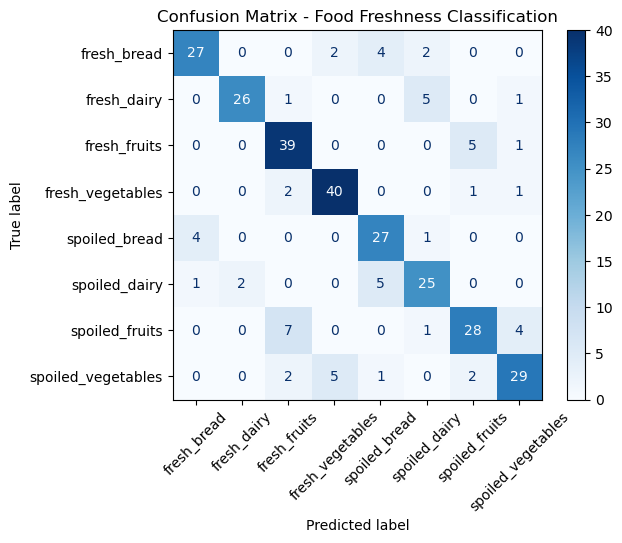

In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Test generator ko reset karo
test_generator.reset()

# Predictions
predictions = model.predict(test_generator)

# Predicted class
y_pred = np.argmax(predictions, axis=1)

# Actual class
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Display
plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("Confusion Matrix - Food Freshness Classification")
plt.show()